<a href="https://colab.research.google.com/github/tarannump096-cpu/ANN/blob/main/Dogs_vs_Cats_Using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [32]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [41]:
train_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 200 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [39]:
# Verify the number of images loaded by the generators
print(f"Number of training samples: {train_data.samples}")
print(f"Number of testing samples: {test_data.samples}")

# Now you can re-run cell `kGM_6Xf5DVBQ` to train your model.

Number of training samples: 0
Number of testing samples: 0


In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

#create the ANN
model = models.Sequential([
    Input(shape=(64, 64, 3)), # Define input shape using an Input layer as the first layer
    layers.Flatten(),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=1, activation='sigmoid')
])

In [35]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5350 - loss: 1.3105 - val_accuracy: 0.5000 - val_loss: 0.7496
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5450 - loss: 0.7133 - val_accuracy: 0.5000 - val_loss: 0.9277
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4900 - loss: 1.0129 - val_accuracy: 0.5000 - val_loss: 0.8282
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5450 - loss: 0.8568 - val_accuracy: 0.5000 - val_loss: 1.1498
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5500 - loss: 0.8834 - val_accuracy: 0.5000 - val_loss: 1.2762
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4350 - loss: 1.3258 - val_accuracy: 0.5000 - val_loss: 1.7210
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4600 - loss: 1.0601 - val_accuracy: 0.5000 - val_loss: 0.9659
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5100 - loss: 0.8482 - val_accuracy: 0.5000 - val_loss: 0.7178


### Creating Dummy Images

The `ValueError: The PyDataset has length 0` during `model.fit()` occurs because the `ImageDataGenerator` was unable to find any images in the `dataset/train` and `dataset/test` directories. This step creates a set of dummy JPG images for both 'cats' and 'dogs' in the correct folder structure, allowing the `ImageDataGenerator` to proceed.

In [43]:
import os
import numpy as np
from PIL import Image

# Define base directories
base_dir = 'dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Define categories
categories = ['cats', 'dogs']

# Create directories if they don't exist
for dir_path in [train_dir, test_dir]:
    for category in categories:
        path = os.path.join(dir_path, category)
        os.makedirs(path, exist_ok=True)
        print(f"Created directory: {path}")

# Function to create a dummy image
def create_dummy_image(path, filename, size=(64, 64)):
    image_array = np.random.randint(0, 256, (size[0], size[1], 3), dtype=np.uint8)
    img = Image.fromarray(image_array)
    img.save(os.path.join(path, filename))

# Create dummy images for training data
print("\nCreating dummy training images...")
for category in categories:
    category_path = os.path.join(train_dir, category)
    for i in range(100): # Create 100 dummy images per category for training
        create_dummy_image(category_path, f'{category}_{i:03d}.jpg')

# Create dummy images for testing data
print("Creating dummy testing images...")
for category in categories:
    category_path = os.path.join(test_dir, category)
    for i in range(20): # Create 20 dummy images per category for testing
        create_dummy_image(category_path, f'{category}_{i:03d}.jpg')

print("Dummy images created successfully.")


Created directory: dataset/train/cats
Created directory: dataset/train/dogs
Created directory: dataset/test/cats
Created directory: dataset/test/dogs

Creating dummy training images...
Creating dummy testing images...
Dummy images created successfully.


#### Important Next Steps:

1.  **Run this code** to create the dummy image files.
2.  **Re-run cell `Q9jIH9-s7p3C`** (where `train_data` and `test_data` are defined) so that the `ImageDataGenerator` can detect and load these new images.
3.  **Then, re-run cell `kGM_6Xf5DVBQ`** to train your model, which should now have data to process.

In [44]:
loss, accuracy = model.evaluate(test_data)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7871
Accuracy: 0.5


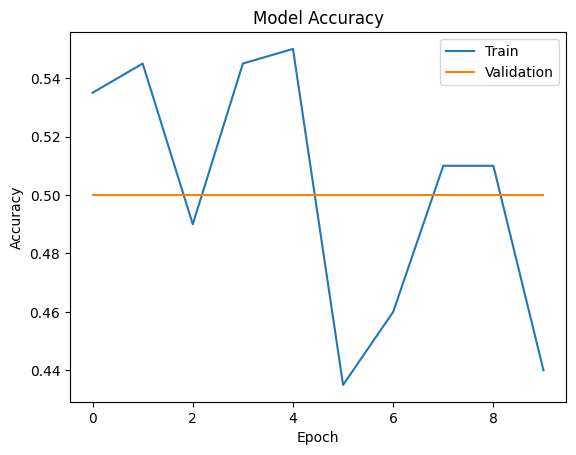

In [45]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [47]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    'dataset/train/dogs/dogs_000.jpg', # Changed to a valid dummy image path
    target_size=(64, 64)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

result = model.predict(img_array)

if result[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Cat


In [48]:
model.save("dogs_vs_cats_ann.h5")